In [11]:
from src.adapters.registry import build_adapter
from omegaconf import DictConfig, OmegaConf
import hydra

In [15]:
import hydra
from omegaconf import DictConfig, OmegaConf
from hydra import initialize_config_dir, compose

# Initialize Hydra with your config directory
config_dir = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/runs_hydra/config"
with initialize_config_dir(config_dir=config_dir, version_base="1.3"):
    # Load the config
    cfg = compose(config_name="config")  # "config" refers to config.yaml
    print(OmegaConf.to_yaml(cfg))  # Print the resolved config

model:
  name: rtdetr
  checkpoint: PekingU/rtdetr_r50vd
  confidence_threshold: 0.05
  num_classes: 80
  id2label:
    0: dugong
training:
  lr: 6.2e-05
  backbone_lr_factor: 0.07
  weight_decay: 0.0025
  batch_size: 8
  max_epochs: 100
  early_stopping_patience: 21
  warmup_epochs: 2
  gradient_clip_val: 0.72
  precision: 16-mixed
  log_every_n_steps: 20
  num_workers: 4
augmentation:
  name: flip_color
  horizontal_flip_p: 0.7
  vertical_flip_p: 0.7
  brightness_limit: 0.2
  contrast_limit: 0.2
  brightness_contrast_p: 0.5
  hue_shift_limit: 10
  sat_shift_limit: 20
  val_shift_limit: 10
  hue_saturation_p: 0.3
  blur_limit: 5
  blur_p: 0.2
paths:
  patch_folder: /share/home/e2406743/dataset/exported_img/new_dataset_flplan200
  selections_json: /share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/splits_json/aclr_v3_ball_seed012_6cluster.json
  resolved_paths_json: /share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/splits_json/aclr_v3_ball_seed012_6

In [13]:
from src.training.logger_factory import build_logger

In [10]:
cfg.schema

'NWW'

In [ ]:
cfg.exper

In [16]:
logger = build_logger(cfg)

  [logger] W&B disabled — writing CSV logs to /share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/logs_logger_flplan/aclr_ball/S0_NWW_p10_aclr/NWW_p10_seed0_0610_2238


In [15]:
new_check = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/checkpoints/NNN_NC_SEED63_augm_0506_0140"
OmegaConf.update(cfg, "model.checkpoint", new_check)

In [10]:
print(OmegaConf.to_yaml(cfg))  # Print the resolved config

model:
  name: rtdetr
  checkpoint: PekingU/rtdetr_r50vd
  confidence_threshold: 0.05
  num_classes: 80
  id2label:
    0: dugong
training:
  lr: 6.2e-05
  backbone_lr_factor: 0.07
  weight_decay: 0.0025
  batch_size: 8
  max_epochs: 100
  early_stopping_patience: 21
  warmup_epochs: 2
  gradient_clip_val: 0.72
  precision: 16-mixed
  log_every_n_steps: 20
  num_workers: 4
augmentation:
  name: flip_color_ot
  ot_n_samples: 300
  ot_reg_e: 0.1
  ot_max_pool_size: 50
  ot_p: 0.9
  ot_reference_json: /share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/splits_json/references_ot.json
paths:
  patch_folder: /share/home/e2406743/dataset/exported_img/new_dataset_flplan200
  selections_json: /share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/splits_json/splits_seeds012.json
  resolved_paths_json: /share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/splits_json/splits_seeds012_mapped.json
  output_dir: /share/home/e2406743/code/Dugongs_IRISA-MA

In [3]:
from src.data.data_augmentation import build_augmentor
augmentor = build_augmentor(cfg.get("augmentation"))

In [4]:
cfg.paths.resolved_paths_json = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/splits_json/aclr_v3_ball_seed012_6cluster_mapped.json"

In [5]:
from transformers import AutoImageProcessor
from src.data.datamodule import DugongDataModule

processor = AutoImageProcessor.from_pretrained(cfg.model.checkpoint)

# WITH augmentation — mirrors exactly what train.py does
dm_aug = DugongDataModule(
    resolved_paths_json = cfg.paths.resolved_paths_json,
    seed        = cfg.seed,
    partition   = cfg.partition,
    method      = cfg.method,
    processor   = processor,
    batch_size  = cfg.training.batch_size,
    augmentor   = augmentor,
    num_workers = 0,       # 0 for notebook — avoids multiprocessing issues
    pin_memory  = False,
)
dm_aug.setup("fit")

# WITHOUT augmentation — for side-by-side comparison
dm_raw = DugongDataModule(
    resolved_paths_json = cfg.paths.resolved_paths_json,
    seed        = cfg.seed,
    partition   = cfg.partition,
    method      = cfg.method,
    processor   = processor,
    batch_size  = cfg.training.batch_size,
    augmentor   = None,
    num_workers = 0,
    pin_memory  = False,
)
dm_raw.setup("fit")

print(f"Train samples : {len(dm_aug.train_dataset)}")
print(f"Val   samples : {len(dm_aug.val_dataset)}")

The image processor of type `RTDetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


  DataModule setup | seed=0 | partition=p10 | method=aclr
    train=26  val=44  test=61
  DataModule setup | seed=0 | partition=p10 | method=aclr
    train=26  val=44  test=61
Train samples : 26
Val   samples : 44


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


def draw_boxes(ax, image_path, boxes_cxcywh, title="", color="lime"):
    """
    Draw bounding boxes on the original image.
    boxes_cxcywh : (N, 4) normalised [cx, cy, w, h] tensor or array
    """
    img          = Image.open(image_path).convert("RGB")
    img_w, img_h = img.size
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

    boxes = boxes_cxcywh.numpy() if hasattr(boxes_cxcywh, "numpy") else np.array(boxes_cxcywh)

    for cx, cy, w, h in boxes:
        x_min = (cx - w / 2) * img_w
        y_min = (cy - h / 2) * img_h
        abs_w = w * img_w
        abs_h = h * img_h
        rect  = patches.Rectangle(
            (x_min, y_min), abs_w, abs_h,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)

    ax.set_xlabel(f"{len(boxes)} box(es)", fontsize=8)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch


def tensor_to_image(pixel_values):
    """
    Convert pixel_values tensor (C, H, W) back to displayable uint8 (H, W, 3).

    RTDetrImageProcessorFast with do_normalize=false only rescales by 1/255.
    So we just multiply back by 255 — no mean/std inversion needed.
    """
    img = pixel_values.float().numpy().transpose(1, 2, 0)  # (H, W, C)
    img = np.clip(img * 255, 0, 255).astype(np.uint8)
    return img


def draw_boxes_on_tensor(ax, pixel_values, boxes_cxcywh, title="", color="lime"):
    """
    Draw bounding boxes on a pixel_values tensor (already augmented).

    Parameters
    ----------
    ax             : matplotlib Axes
    pixel_values   : (C, H, W) float tensor from the processor
    boxes_cxcywh   : (N, 4) normalised [cx, cy, w, h] tensor
    """
    img          = tensor_to_image(pixel_values)
    img_h, img_w = img.shape[:2]

    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

    boxes = boxes_cxcywh.numpy() if hasattr(boxes_cxcywh, "numpy") else np.array(boxes_cxcywh)

    for cx, cy, w, h in boxes:
        x_min = (cx - w / 2) * img_w
        y_min = (cy - h / 2) * img_h
        abs_w = w * img_w
        abs_h = h * img_h
        rect  = patches.Rectangle(
            (x_min, y_min), abs_w, abs_h,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)

    ax.set_xlabel(f"{len(boxes)} box(es)", fontsize=8)


def draw_boxes_on_path(ax, image_path, boxes_cxcywh, title="", color="lime"):
    """
    Draw bounding boxes on the raw image read from disk.
    Use this for the ORIGINAL (non-augmented) column only.
    """
    img          = Image.open(image_path).convert("RGB")
    img_w, img_h = img.size

    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

    boxes = boxes_cxcywh.numpy() if hasattr(boxes_cxcywh, "numpy") else np.array(boxes_cxcywh)

    for cx, cy, w, h in boxes:
        x_min = (cx - w / 2) * img_w
        y_min = (cy - h / 2) * img_h
        abs_w = w * img_w
        abs_h = h * img_h
        rect  = patches.Rectangle(
            (x_min, y_min), abs_w, abs_h,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)

    ax.set_xlabel(f"{len(boxes)} box(es)", fontsize=8)

Showing 6 samples with boxes: [0, 1, 3, 4, 5, 7]


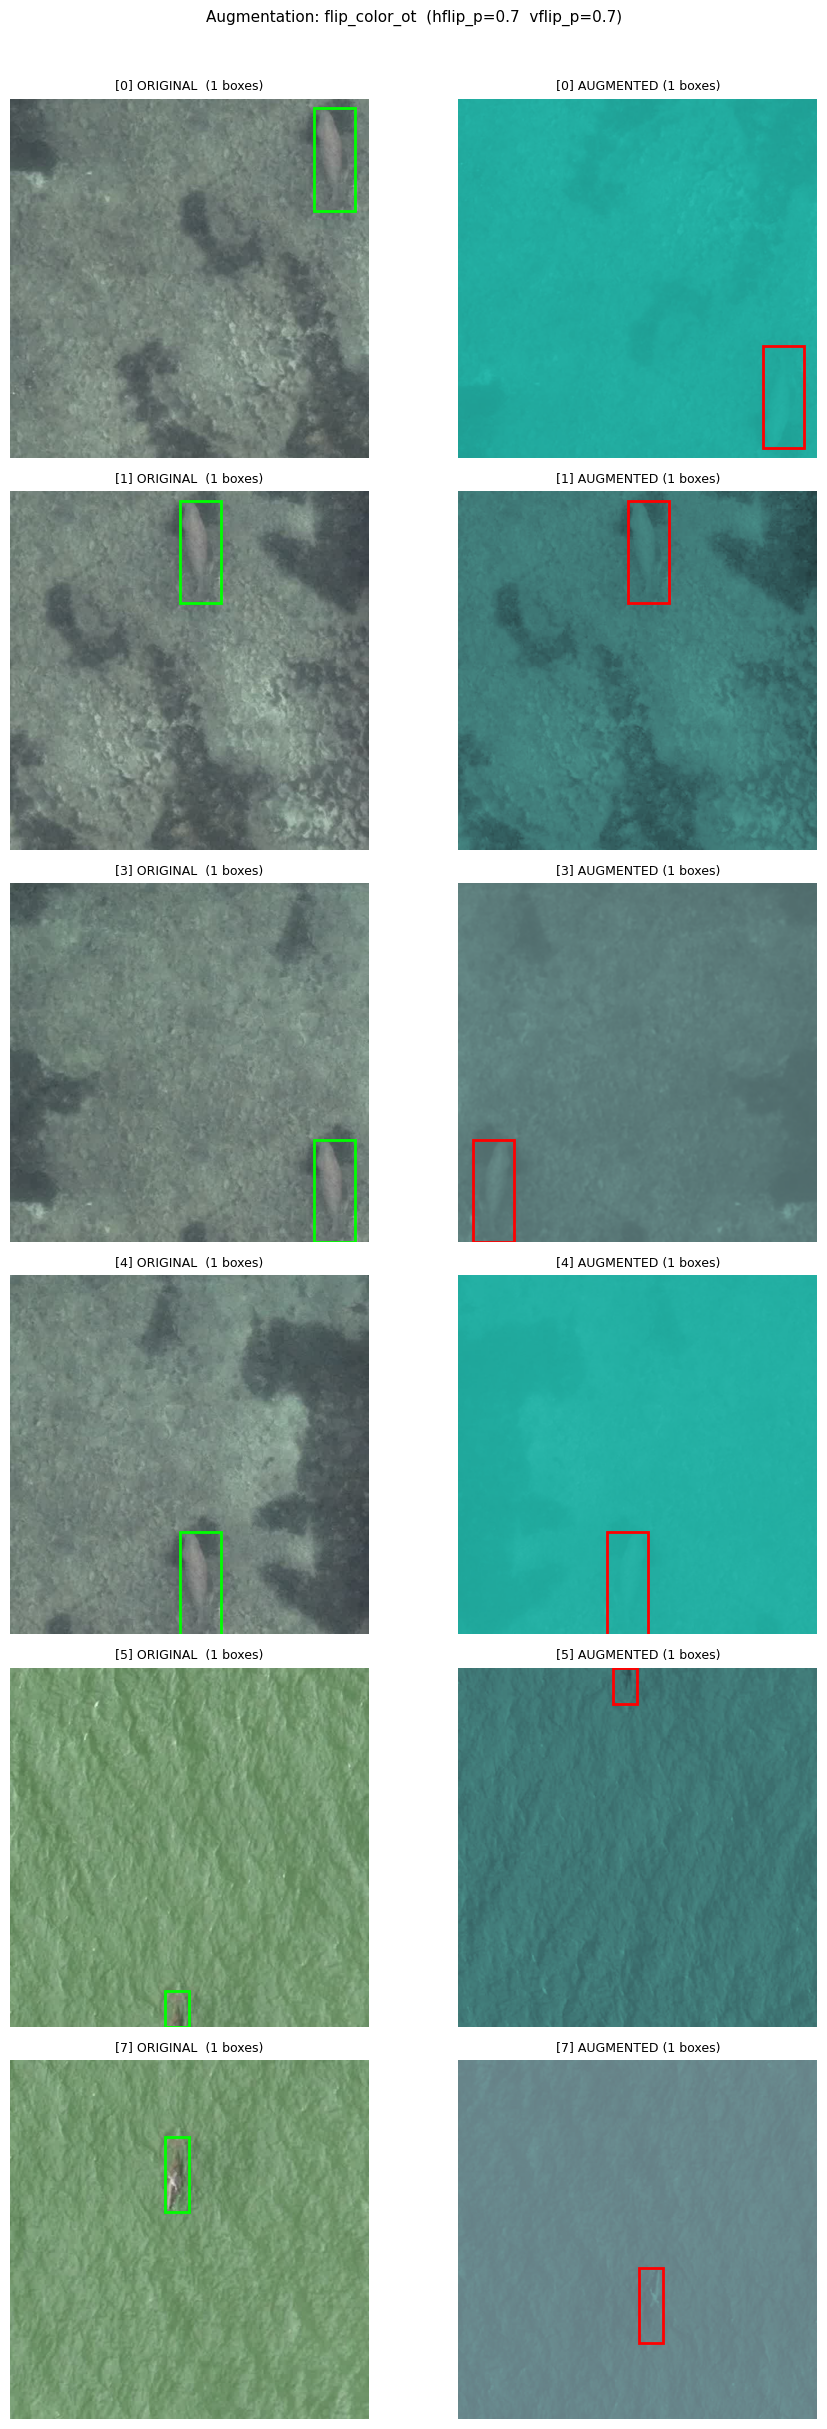

In [9]:
N_SHOW = 6

indices_with_boxes = [
    i for i in range(len(dm_raw.train_dataset))
    if dm_raw.train_dataset[i][1]["boxes"].shape[0] > 0
][:N_SHOW]

print(f"Showing {len(indices_with_boxes)} samples with boxes: {indices_with_boxes}")

fig, axes = plt.subplots(len(indices_with_boxes), 2,
                          figsize=(10, 4 * len(indices_with_boxes)))

if len(indices_with_boxes) == 1:
    axes = [axes]

for row, idx in enumerate(indices_with_boxes):
    raw_pv, raw_labels, raw_path, _ = dm_raw.train_dataset[idx]
    aug_pv, aug_labels, aug_path, _ = dm_aug.train_dataset[idx]

    # Original — read from disk (no normalisation artefacts)
    draw_boxes_on_path(
        axes[row][0], raw_path, raw_labels["boxes"],
        title=f"[{idx}] ORIGINAL  ({raw_labels['boxes'].shape[0]} boxes)",
        color="lime",
    )

    # Augmented — recover image from the processor tensor
    draw_boxes_on_tensor(
        axes[row][1], aug_pv, aug_labels["boxes"],
        title=f"[{idx}] AUGMENTED ({aug_labels['boxes'].shape[0]} boxes)",
        color="red",
    )

plt.suptitle(
    f"Augmentation: {cfg.augmentation.name}  "
    f"(hflip_p={cfg.augmentation.get('horizontal_flip_p', 0.7)}  "
    f"vflip_p={cfg.augmentation.get('vertical_flip_p', 0.7)})",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

### Evaluate Optimal Transport 

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage
import random
import ot as pot


def _run_ot_transfer(src_flat, ref_pixels, n_samples, reg_e):
    """
    Core OT logic — identical to OTColorTransfer.apply() but returns
    the transported flat array so callers can do what they want with it.

    Parameters
    ----------
    src_flat  : (H*W, 3) float64 source pixels in [0, 1]
    ref_pixels: (N_ref, 3) float64 reference pixels in [0, 1]
    n_samples : int pixels to sample for SinkhornTransport fit
    reg_e     : float Sinkhorn regularisation

    Returns
    -------
    transported : (H*W, 3) float64 clipped to [0, 1]
    """
    idx_s = np.random.randint(0, src_flat.shape[0],   size=n_samples)
    idx_t = np.random.randint(0, ref_pixels.shape[0], size=n_samples)

    Xs = src_flat[idx_s]
    Xt = ref_pixels[idx_t]

    transport = pot.da.SinkhornTransport(reg_e=reg_e, verbose=False)
    transport.fit(Xs=Xs, Xt=Xt)

    transported = transport.transform(Xs=src_flat)
    return np.clip(transported, 0.0, 1.0)


def plot_ot_transfer(
    ot_transform,
    image_path:    str,
    label_path:    str  | None = None,
    ref_idx:       int  | None = None,
    figsize:       tuple       = (15, 5),
):
    """
    Three-panel plot for a single source tile:
      [Source] → [Reference] → [OT Result]

    Parameters
    ----------
    ot_transform : OTColorTransfer instance (already initialised)
    image_path   : path to the source tile image
    label_path   : optional path to the YOLO .txt label file — draws boxes
                   on source and result panels if provided
    ref_idx      : optional int to fix which reference to use.
                   If None, drawn randomly (Option A behaviour).
    figsize      : figure size
    """
    # ── Load source ───────────────────────────────────────────────────────
    src_img      = PILImage.open(image_path).convert("RGB")
    src_np       = np.array(src_img)                          # (H, W, 3) uint8
    H, W, _      = src_np.shape
    src_f64      = src_np.astype(np.float64) / 255.0
    src_flat     = src_f64.reshape(-1, 3)

    # ── Pick reference ────────────────────────────────────────────────────
    if ref_idx is None:
        ref_idx = random.randint(0, len(ot_transform.pool) - 1)

    ref_entry    = ot_transform.pool[ref_idx]
    ref_pixels   = ref_entry["pixels"]                        # (N_ref, 3) float64
    ref_path     = ref_entry["path"]

    ref_img      = PILImage.open(ref_path).convert("RGB")
    ref_np       = np.array(ref_img)

    # ── Run OT ────────────────────────────────────────────────────────────
    transported  = _run_ot_transfer(
        src_flat, ref_pixels,
        ot_transform.n_samples,
        ot_transform.reg_e,
    )
    result_np    = (transported.reshape(H, W, 3) * 255).astype(np.uint8)

    # ── Load boxes if label provided ──────────────────────────────────────
    boxes_cxcywh = []
    if label_path is not None:
        from pathlib import Path
        lines = Path(label_path).read_text().strip().splitlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            _, cx, cy, bw, bh = map(float, parts)
            boxes_cxcywh.append((cx, cy, bw, bh))

    def _draw_boxes(ax, img_w, img_h, color):
        for cx, cy, bw, bh in boxes_cxcywh:
            x_min = (cx - bw / 2) * img_w
            y_min = (cy - bh / 2) * img_h
            rect  = patches.Rectangle(
                (x_min, y_min), bw * img_w, bh * img_h,
                linewidth=2, edgecolor=color, facecolor="none",
            )
            ax.add_patch(rect)

    # ── Mean RGB stats for annotation ─────────────────────────────────────
    def _rgb_str(arr_uint8):
        m = arr_uint8.mean(axis=(0, 1))
        return f"mean RGB  R={m[0]:.1f}  G={m[1]:.1f}  B={m[2]:.1f}"

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # Panel 1 — source
    axes[0].imshow(src_np)
    axes[0].set_title("Source tile", fontsize=11)
    axes[0].set_xlabel(_rgb_str(src_np), fontsize=8)
    axes[0].axis("off")
    _draw_boxes(axes[0], W, H, color="lime")

    # Panel 2 — reference
    axes[1].imshow(ref_np)
    axes[1].set_title(f"Reference  [idx={ref_idx}]", fontsize=11)
    axes[1].set_xlabel(
        f"{ref_path.split('/')[-1]}\n{_rgb_str(ref_np)}", fontsize=8
    )
    axes[1].axis("off")

    # Panel 3 — OT result
    axes[2].imshow(result_np)
    axes[2].set_title("OT transfer result", fontsize=11)
    axes[2].set_xlabel(_rgb_str(result_np), fontsize=8)
    axes[2].axis("off")
    _draw_boxes(axes[2], W, H, color="red")

    plt.suptitle(
        f"OT color transfer  |  n_samples={ot_transform.n_samples}  "
        f"reg_e={ot_transform.reg_e}  p={ot_transform.p}",
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    plt.show()


def plot_ot_grid(
    ot_transform,
    image_paths:  list[str],
    label_paths:  list[str] | None = None,
    figsize_row:  tuple            = (15, 4),
):
    """
    Grid plot — one row per source tile, three columns per row:
      [Source] → [Reference] → [OT Result]

    Parameters
    ----------
    ot_transform : OTColorTransfer instance
    image_paths  : list of source tile image paths
    label_paths  : optional list of YOLO label paths, 1:1 with image_paths.
                   Pass None to skip box drawing.
    figsize_row  : (width, height) per row — total height scales with n rows
    """
    n      = len(image_paths)
    labels = label_paths if label_paths is not None else [None] * n

    assert len(labels) == n, (
        f"label_paths length ({len(labels)}) must match "
        f"image_paths length ({n})."
    )

    fig, axes = plt.subplots(
        n, 3,
        figsize=(figsize_row[0], figsize_row[1] * n),
    )

    # Ensure axes is always 2D even for n=1
    if n == 1:
        axes = [axes]

    for row, (img_path, lbl_path) in enumerate(zip(image_paths, labels)):

        # ── Load source ───────────────────────────────────────────────────
        src_img  = PILImage.open(img_path).convert("RGB")
        src_np   = np.array(src_img)
        H, W, _  = src_np.shape
        src_f64  = src_np.astype(np.float64) / 255.0
        src_flat = src_f64.reshape(-1, 3)

        # ── Random reference ──────────────────────────────────────────────
        ref_idx    = random.randint(0, len(ot_transform.pool) - 1)
        ref_entry  = ot_transform.pool[ref_idx]
        ref_pixels = ref_entry["pixels"]
        ref_path   = ref_entry["path"]
        print(f"here:{ref_path}")
        ref_np     = np.array(PILImage.open(ref_path).convert("RGB"))

        # ── Run OT ────────────────────────────────────────────────────────
        transported = _run_ot_transfer(
            src_flat, ref_pixels,
            ot_transform.n_samples,
            ot_transform.reg_e,
        )
        result_np = (transported.reshape(H, W, 3) * 255).astype(np.uint8)

        # ── Load boxes ────────────────────────────────────────────────────
        boxes_cxcywh = []
        if lbl_path is not None:
            from pathlib import Path as _Path
            lines = _Path(lbl_path).read_text().strip().splitlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                _, cx, cy, bw, bh = map(float, parts)
                boxes_cxcywh.append((cx, cy, bw, bh))

        def _draw(ax, img_w, img_h, color):
            for cx, cy, bw, bh in boxes_cxcywh:
                x_min = (cx - bw / 2) * img_w
                y_min = (cy - bh / 2) * img_h
                rect  = patches.Rectangle(
                    (x_min, y_min), bw * img_w, bh * img_h,
                    linewidth=2, edgecolor=color, facecolor="none",
                )
                ax.add_patch(rect)

        def _rgb(arr):
            m = arr.mean(axis=(0, 1))
            return f"R={m[0]:.1f} G={m[1]:.1f} B={m[2]:.1f}"

        # ── Fill row ──────────────────────────────────────────────────────

        axes[row][0].imshow(src_np)
        axes[row][0].set_title(f"[{row}] Source", fontsize=9)
        axes[row][0].set_xlabel(_rgb(src_np), fontsize=7)
        axes[row][0].axis("off")
        _draw(axes[row][0], W, H, "lime")

        axes[row][1].imshow(ref_np)
        axes[row][1].set_title(f"Reference [idx={ref_idx}]", fontsize=9)
        axes[row][1].set_xlabel(Path(str(ref_path)).stem, fontsize=7)
        axes[row][1].axis("off")

        axes[row][2].imshow(result_np)
        axes[row][2].set_title("OT result", fontsize=9)
        axes[row][2].set_xlabel(_rgb(result_np), fontsize=7)
        axes[row][2].axis("off")
        _draw(axes[row][2], W, H, "red")

    plt.suptitle(
        f"OT color transfer grid  |  n_samples={ot_transform.n_samples}  "
        f"reg_e={ot_transform.reg_e}",
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    plt.show()

In [21]:
augmentor.transforms[-1].pool[5]['path']

'/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_214__tile_2200_0_n.jpg'

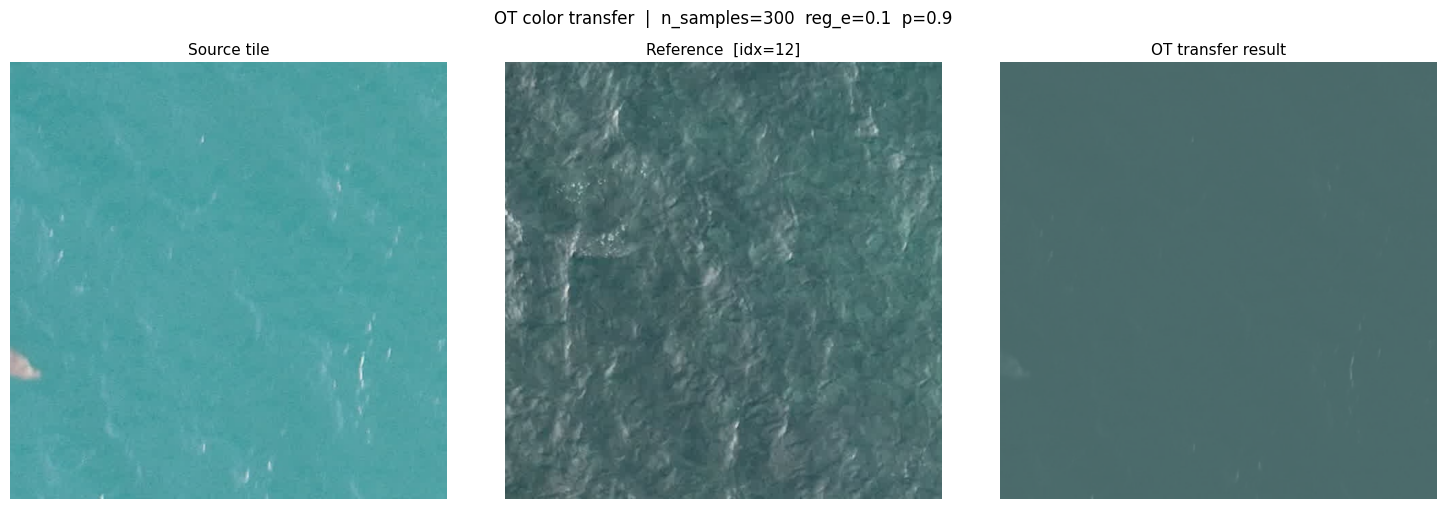

In [ ]:
# Single sample
plot_ot_transfer(
    ot_transform = augmentor.transforms[-1],   # OTColorTransfer is last in pipeline
    image_path   =   "/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_P4P_UM_M48_F1_2025_GSP-697e1055e6795_773__tile_2200_440_p.jpg",

)



In [29]:
from pathlib import Path

here:/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_213__tile_440_4400_p.jpg
here:/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_213__tile_0_4400_p.jpg
here:/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_214__tile_3080_4640_p.jpg
here:/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_213__tile_0_4400_p.jpg
here:/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_214__tile_3080_4640_p.jpg


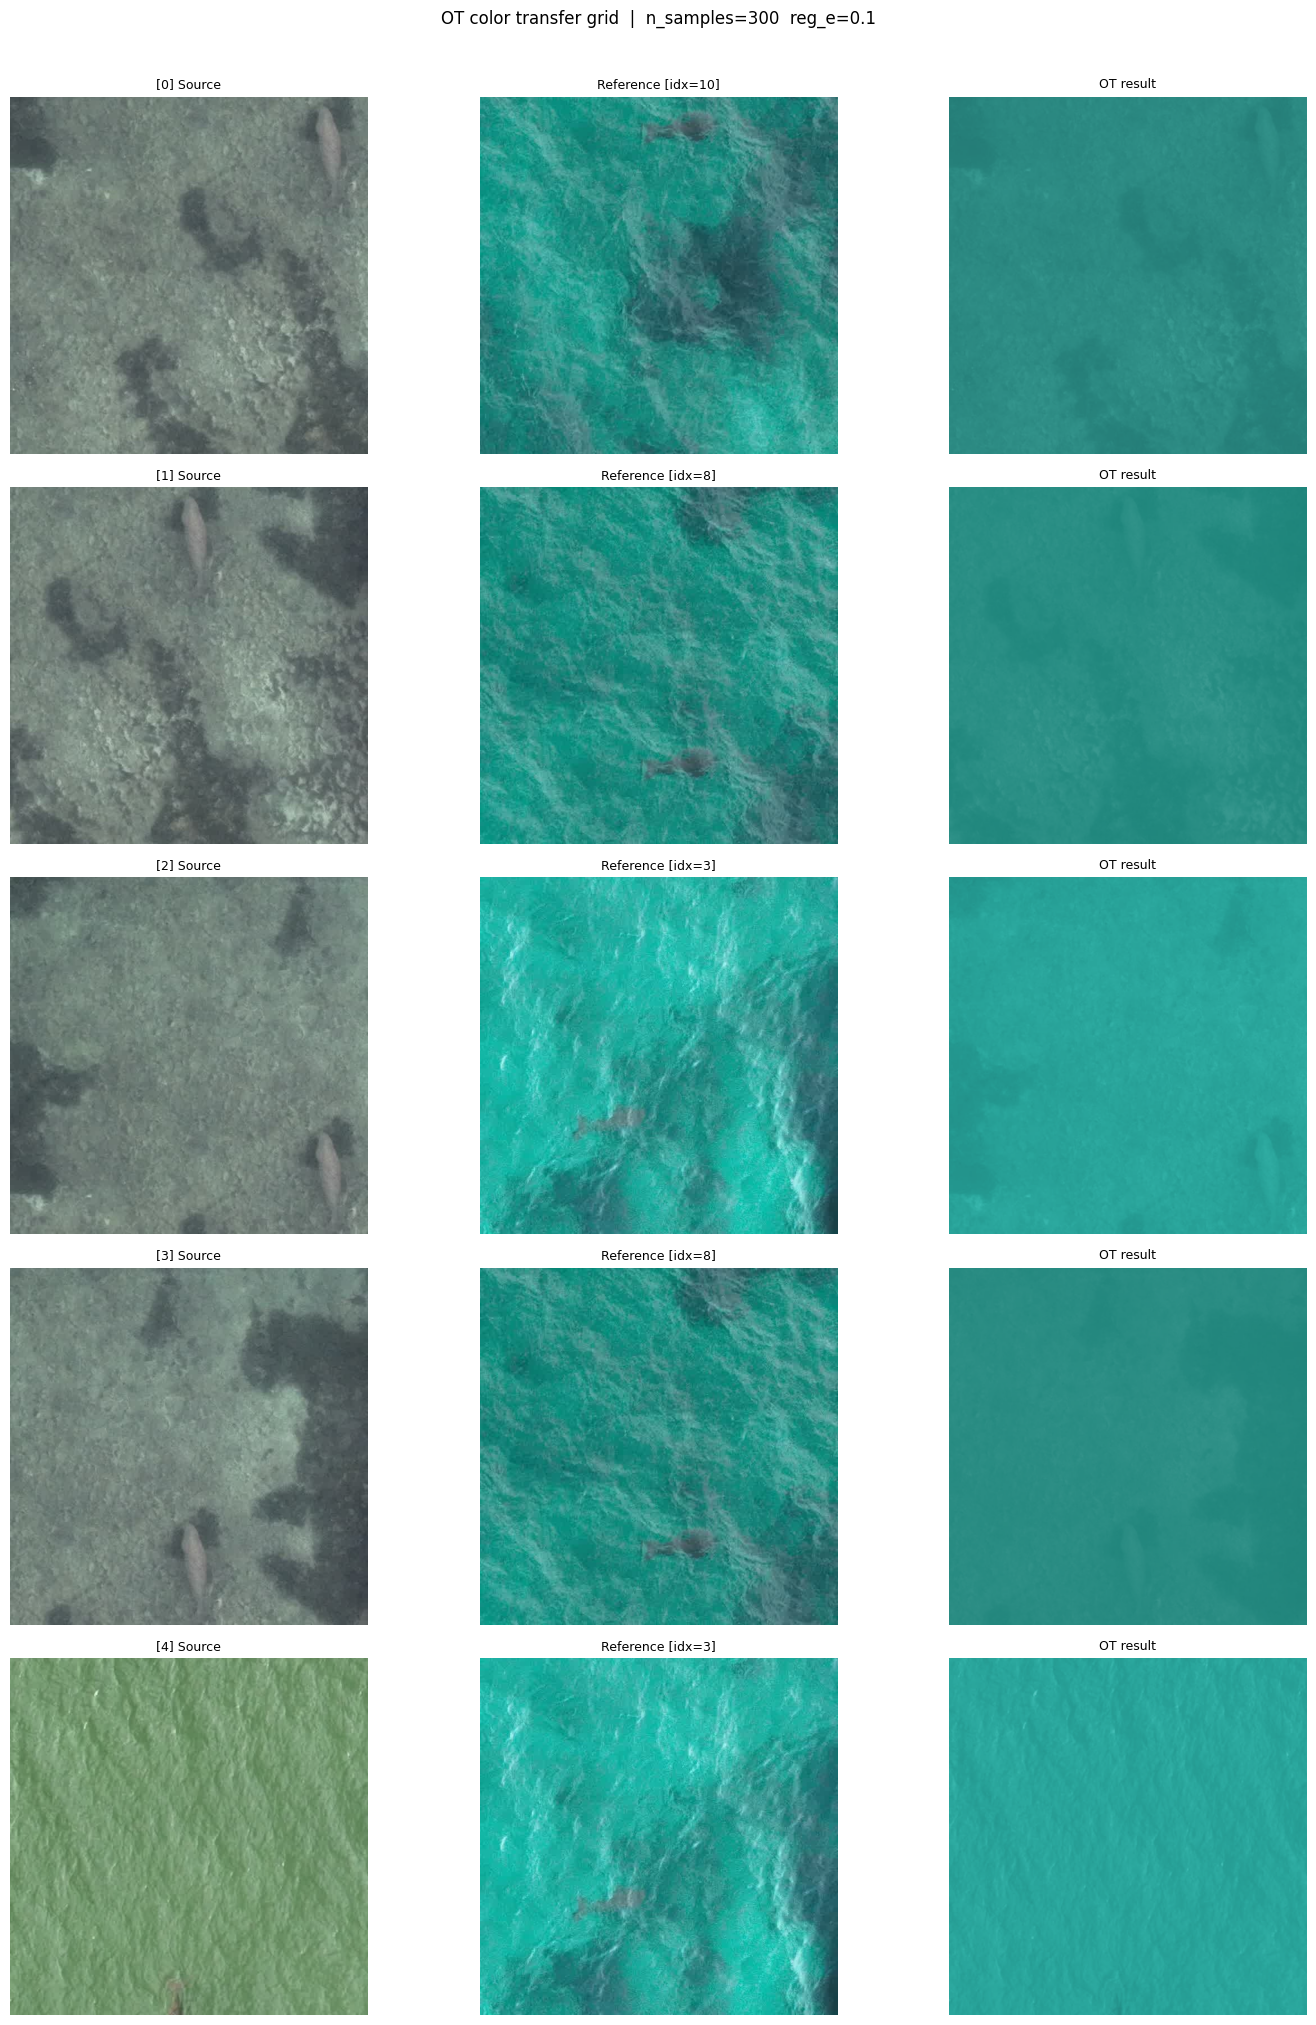

In [31]:
# Grid — pick a few tiles with boxes from your earlier stress-test indices
plot_ot_grid(
    ot_transform = augmentor.transforms[-1],
    image_paths  = [dm_raw.train_dataset[i][2] for i in indices_with_boxes[:5]],
    label_paths  = None,   # or derive from image paths if needed
)